In [ ]:
#WORKSHEET - 3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#TASK 1: Implementation of MCP Neurons:
#AND Function
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Test
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

print(MCP_Neurons_AND(X1, X2, T))



[0, 0, 0, 1]


In [3]:
#OR Gate Logic Threshold = 1
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Test
T = 1
print(MCP_Neurons_OR(X1, X2, T))

[0, 1, 1, 1]


Question - 1: List out all the limitations of MCP - Neurons.
**Ans-
-Cannot learn from the data (no traning)
-No weights(all inputs treated equally)
-Cannot solve non linear problems (like xor)
-Fixed threshold
-very simple model (not practical for real problems)**



Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
**Ans-
-XOR is not linearly separable
-MCP neuron cannot solve XOR with single neuron
-You would need multiple neurons (multi-layer network) **


In [6]:
#Task 2: Perceptron Algorithm for 0 vs 1 Classification
df = pd.read_csv("mnist_0_and_1.csv")

X = df.drop(columns=["label"]).values
y = df["label"].values

print(X.shape)
print(y.shape)

(12665, 784)
(12665,)


Question - 1: What does the shape of X represent?
**Ans- It shows how many images and how many pixels each image has.
12665 = number of images
784 = pixels in each image**



Question - 2: What does the shape of y represent?
**Ans-It shows how many labels there are, one for each image.
12665 = number of labels
Each label matches one image**

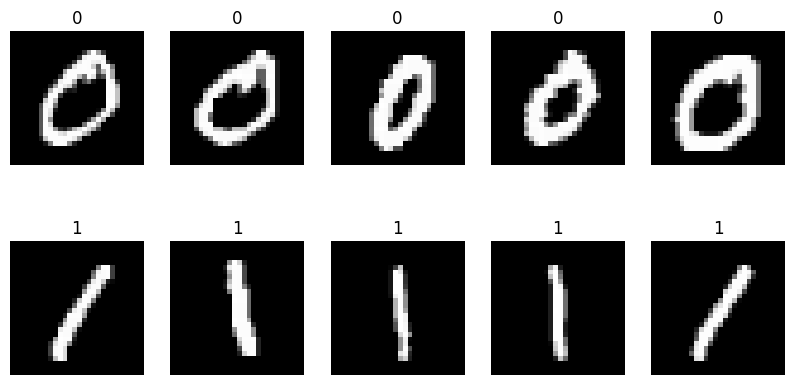

In [7]:
#Visualize Data
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(5):
    axes[0,i].imshow(images_0[i].reshape(28,28), cmap='gray')
    axes[0,i].set_title("0")
    axes[0,i].axis("off")

    axes[1,i].imshow(images_1[i].reshape(28,28), cmap='gray')
    axes[1,i].set_title("1")
    axes[1,i].axis("off")

plt.show()

In [8]:
#Initialize Weights and Bias:
weights = np.zeros(X.shape[1])
bias = 0

learning_rate = 0.1
epochs = 100

Question - 3: What does the weights array represent in this context?
**Ans-The weights array represents the importance of each pixel (feature) in making the prediction.
There are 784 weights → one for each pixel
Each weight tells how much that pixel affects the result**



Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?
**Ans- We initialize weights to zero to start the learning process from a neutral point.
Effect on training:
-The model learns from scratch
-Weights are updated step-by-step during training
-If not updated properly, learning can be slow**

In [9]:
#Implement a Decision Function or Activation Function:
def decision_function(X, weights, bias):
    z = np.dot(X, weights) + bias
    return np.where(z >= 0, 1, 0)

In [10]:
#Implement the Perceptron Learning Algorithm:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        for i in range(len(X)):

            z = np.dot(X[i], weights) + bias
            y_pred = 1 if z >= 0 else 0

            if y_pred != y[i]:
                weights += learning_rate * (y[i] - y_pred) * X[i]
                bias += learning_rate * (y[i] - y_pred)

    predictions = decision_function(X, weights, bias)
    accuracy = np.mean(predictions == y)

    return weights, bias, accuracy

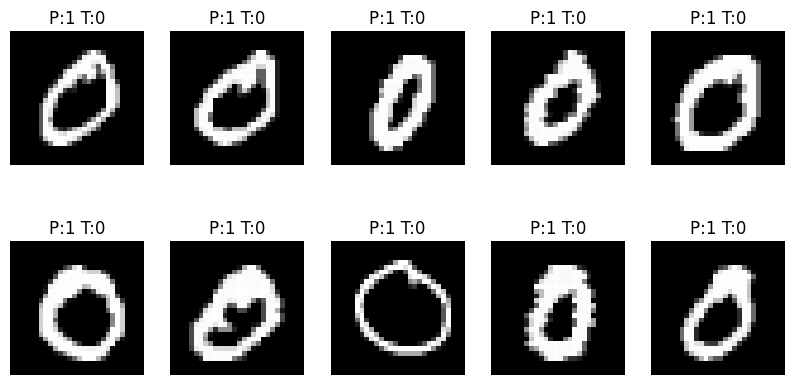

In [11]:
#Visualizing the Misclassified Image:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10,5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28,28), cmap='gray')
        ax.set_title(f"P:{y_pred[idx]} T:{y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?
**Ans-Computes weighted sum of inputs**


Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?
**Ans - We update weights bias to reduce error**


 Question - 7:Why is the final accuracy important, and what do you expect it to be?
 **Ans-Accuracy tells how many predictions are correct**


 Question - 8:What does misclassified idx store, and how is it used in this code?
 **Ans-Stores indexes of wrongly predicted images**


Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?
**Ans-Model performed perfectly**

In [12]:
#Task 3: Perceptron Algorithm for 3 vs 5 Classification.
df = pd.read_csv("mnist_3_and_5.csv")

In [14]:
X = df.drop(columns=["label"]).values
y = df["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


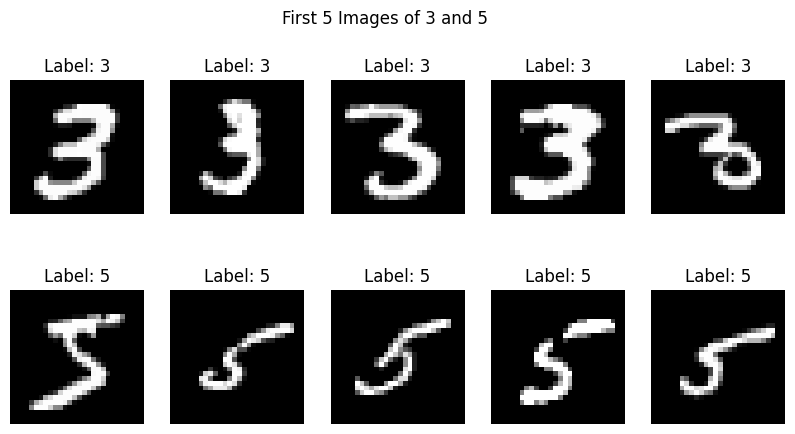

In [15]:
#Visualize Data
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5")
plt.show()

In [16]:
#Converting Labels
y = np.where(y == 3, 0, 1)

In [17]:
#Initialize Weights and Bias:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

In [18]:
#Implement a Decision Function or Activation Function:
def decision_function(X, weights, bias):
    z = np.dot(X, weights) + bias
    return np.where(z >= 0, 1, 0)

In [19]:
#Implement the Perceptron Learning Algorithm:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            z = np.dot(X[i], weights) + bias
            y_pred = 1 if z >= 0 else 0

            if y_pred == y[i]:
                correct += 1
            else:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

    accuracy = correct / len(X)
    return weights, bias, accuracy

In [20]:
#Model Train
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)


Final Accuracy: 0.9857716161984678


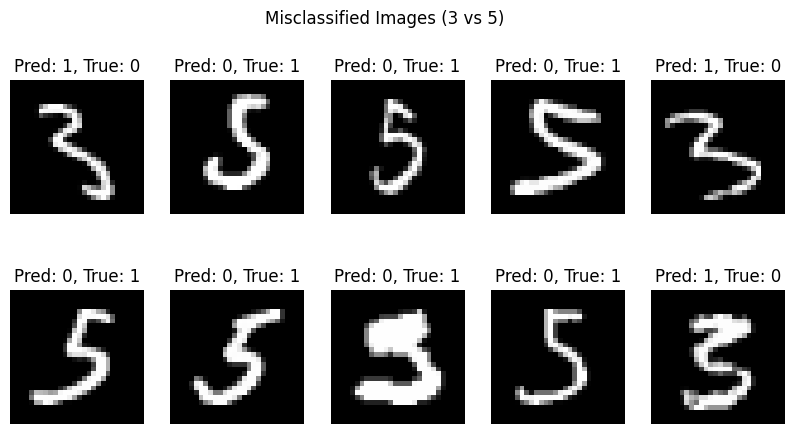

In [21]:
#Visualizing Misclassified Images
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")